GD Epoch 0, Loss: 2.3320
GD Epoch 10, Loss: 0.7516
GD Epoch 20, Loss: 0.5675
GD Epoch 30, Loss: 0.4882
GD Epoch 40, Loss: 0.4408
Adam Epoch 10, Loss: 0.5924
Adam Epoch 20, Loss: 0.3776
Adam Epoch 30, Loss: 0.2909
Adam Epoch 40, Loss: 0.2380
Adam Epoch 50, Loss: 0.2021


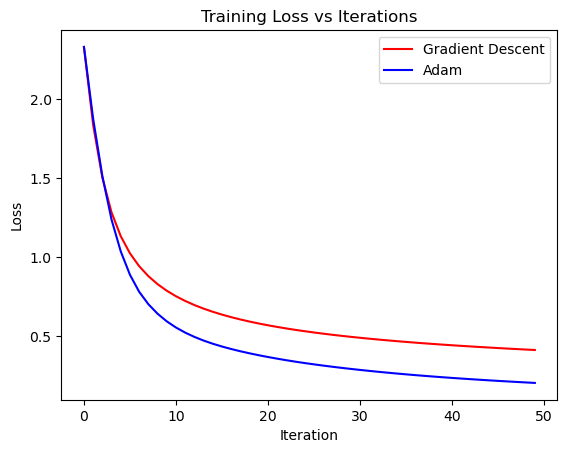

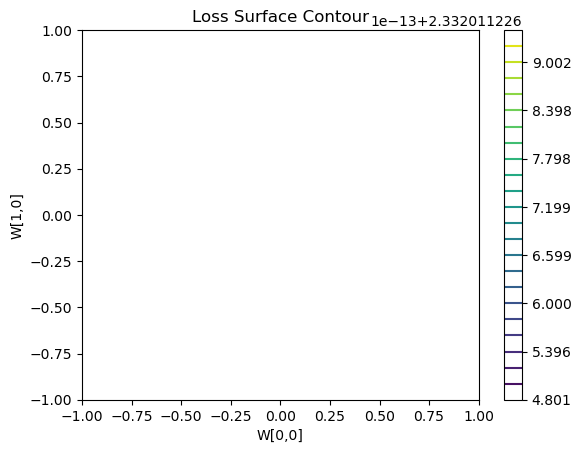

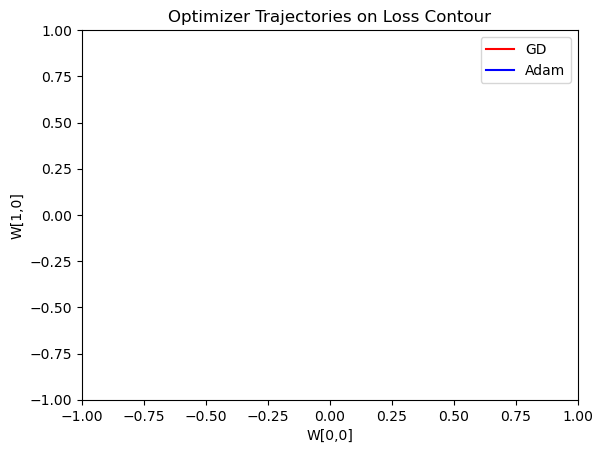

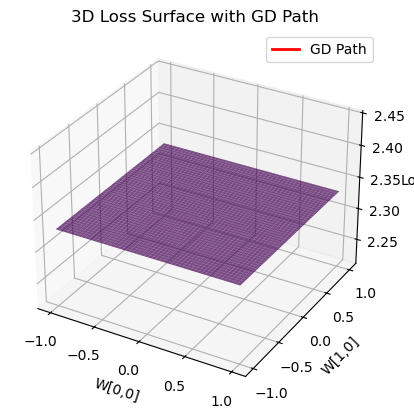

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# =========================
# 1. LOAD AND PREPARE DATA
# =========================

(x_train, y_train), _ = mnist.load_data()

# Reduce dataset size for faster visualization (optional)
x_train = x_train[:2000]
y_train = y_train[:2000]

# Flatten images and normalize pixels
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0

# One-hot encode labels
y_train_onehot = to_categorical(y_train, 10)

# =========================
# 2. DEFINE MODEL FUNCTIONS
# =========================

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(Y_true, Y_pred):
    return -np.sum(Y_true * np.log(Y_pred + 1e-9)) / Y_true.shape[0]

def compute_gradient(X, Y_true, W):
    Y_pred = softmax(np.dot(X, W))
    grad = np.dot(X.T, (Y_pred - Y_true)) / X.shape[0]
    return grad, Y_pred

# =========================
# 3. OPTIMIZERS
# =========================

def train_gd(X, Y, W_init, lr=0.5, epochs=50):
    W = W_init.copy()
    losses = []
    W_hist = []
    for i in range(epochs):
        grad, Y_hat = compute_gradient(X, Y, W)
        W -= lr * grad
        loss = compute_loss(Y, Y_hat)
        losses.append(loss)
        W_hist.append(W.copy())
        if i % 10 == 0:
            print(f"GD Epoch {i}, Loss: {loss:.4f}")
    return W, losses, W_hist

def train_adam(X, Y, W_init, lr=0.01, epochs=50):
    W = W_init.copy()
    m = np.zeros_like(W)
    v = np.zeros_like(W)
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8
    losses = []
    W_hist = []
    for t in range(1, epochs + 1):
        grad, Y_hat = compute_gradient(X, Y, W)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        W -= lr * m_hat / (np.sqrt(v_hat) + eps)
        loss = compute_loss(Y, Y_hat)
        losses.append(loss)
        W_hist.append(W.copy())
        if t % 10 == 0:
            print(f"Adam Epoch {t}, Loss: {loss:.4f}")
    return W, losses, W_hist

# =========================
# 4. INITIALIZE PARAMETERS
# =========================

np.random.seed(42)
D = x_train.shape[1]  # 784 features
C = y_train_onehot.shape[1]  # 10 classes
W_init = np.random.randn(D, C) * 0.01

# =========================
# 5. TRAIN MODELS
# =========================

W_gd, loss_gd, hist_gd = train_gd(x_train, y_train_onehot, W_init, lr=0.5, epochs=50)
W_adam, loss_adam, hist_adam = train_adam(x_train, y_train_onehot, W_init, lr=0.01, epochs=50)

# =========================
# 6. LOSS VS ITERATION PLOT
# =========================

plt.figure()
plt.plot(loss_gd, label="Gradient Descent", color='red')
plt.plot(loss_adam, label="Adam", color='blue')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss vs Iterations")
plt.legend()
plt.show()

# =========================
# 7. LOSS SURFACE (2D PROJECTION)
# =========================

w1_vals = np.linspace(-1, 1, 50)
w2_vals = np.linspace(-1, 1, 50)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
loss_surface = np.zeros_like(W1)

W_fixed = W_init.copy()

for i in range(len(w1_vals)):
    for j in range(len(w2_vals)):
        W_temp = W_fixed.copy()
        W_temp[0,0] = W1[i,j]
        W_temp[1,0] = W2[i,j]
        Y_hat = softmax(np.dot(x_train, W_temp))
        loss_surface[i,j] = compute_loss(y_train_onehot, Y_hat)

# =========================
# 8. EXTRACT PATHS FOR VISUALIZATION
# =========================

def extract_path(W_hist):
    return [(W[0,0], W[1,0]) for W in W_hist]

gd_path = extract_path(hist_gd)
adam_path = extract_path(hist_adam)

# =========================
# 9. STATIC CONTOUR PLOT
# =========================

plt.figure()
contour = plt.contour(W1, W2, loss_surface, levels=30, cmap='viridis')
plt.colorbar(contour)
plt.xlabel('W[0,0]')
plt.ylabel('W[1,0]')
plt.title("Loss Surface Contour")
plt.show()

# =========================
# 10. 2D CONTOUR ANIMATION (fixed reference)
# =========================

fig, ax = plt.subplots()
ax.contour(W1, W2, loss_surface, levels=30, cmap='viridis')
line_gd, = ax.plot([], [], 'r-', label='GD')
line_adam, = ax.plot([], [], 'b-', label='Adam')
ax.set_xlim(w1_vals.min(), w1_vals.max())
ax.set_ylim(w2_vals.min(), w2_vals.max())
ax.set_xlabel('W[0,0]')
ax.set_ylabel('W[1,0]')
ax.set_title('Optimizer Trajectories on Loss Contour')
ax.legend()

def animate(i):
    if i > 0:
        line_gd.set_data([p[0] for p in gd_path[:i]], [p[1] for p in gd_path[:i]])
        line_adam.set_data([p[0] for p in adam_path[:i]], [p[1] for p in adam_path[:i]])
    return line_gd, line_adam

# Assign to a persistent variable to avoid UserWarning
anim = animation.FuncAnimation(fig, animate, frames=len(gd_path), interval=200, blit=True)
plt.show()

# =========================
# 11. 3D LOSS SURFACE WITH GD PATH
# =========================

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, loss_surface, cmap='viridis', alpha=0.7)

gd_z = []
for w in gd_path:
    W_temp = W_fixed.copy()
    W_temp[0,0], W_temp[1,0] = w
    Y_hat = softmax(np.dot(x_train, W_temp))
    gd_z.append(compute_loss(y_train_onehot, Y_hat))

ax.plot([p[0] for p in gd_path], [p[1] for p in gd_path], gd_z, color='red', label='GD Path', linewidth=2)

ax.set_xlabel('W[0,0]')
ax.set_ylabel('W[1,0]')
ax.set_zlabel('Loss')
ax.set_title('3D Loss Surface with GD Path')
ax.legend()
plt.show()
